# 04 — Walk-Forward Backtest

Out-of-sample pairs trading backtest: 24-month training / 6-month trading windows,
monthly roll (6-month step). Two cost scenarios: **base (10 bps)** and **stress (25 bps)**
per side per leg.

**Methodology (locked in CLAUDE.md):**
- Pair selection: Engle-Granger + BH FDR 10% + half-life [5, 60d] + Hurst H < 0.5
- Signal: rolling 60-day z-score, enter |z|≥2, exit |z|≤0.5, hard stop |z|≥4, time stop 2×HL
- Sizing: inverse-vol weights, max 10 pairs, $1M total capital
- Data: ASX 200 large-caps, within-sector pairs only

**All results are out-of-sample by construction.** Pairs are screened on training data;
the backtest period is strictly after the training window ends.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import logging
import warnings

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import ASX_UNIVERSE, fetch_history, get_close_panel
from src.backtest import run_backtest, compute_metrics, _walk_forward_windows
from src.costs import BASE_BPS, STRESS_BPS

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
)
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', font_scale=0.9)

FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path('../data/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
tickers = [t for sector_tickers in ASX_UNIVERSE.values() for t in sector_tickers]
df = fetch_history(tickers, start='2010-01-01', cache_dir='../data/cache')
prices = get_close_panel(df)

print(f'Panel shape:  {prices.shape}')
print(f'Date range:   {prices.index.min().date()} to {prices.index.max().date()}')

2026-05-03 00:23:16,821 [INFO] Loading cached prices from ../data/cache/prices_2010-01-01_latest.parquet (mtime: 2026-04-29)


Panel shape:  (4126, 45)
Date range:   2010-01-04 to 2026-04-29


## 1. Run walk-forward backtest

Training starts 2010-01-01; first trading window opens 2012-01-01 (after 24m training).
Results are cached to parquet so subsequent runs skip the expensive screening step.

In [3]:
BACKTEST_START = '2012-01-01'
TOTAL_CAPITAL  = 1_000_000.0

cache_pnl   = RESULTS_DIR / 'backtest_daily_pnl.parquet'
cache_trades = RESULTS_DIR / 'backtest_trade_log.parquet'
cache_windows = RESULTS_DIR / 'backtest_window_log.parquet'

if cache_pnl.exists() and cache_trades.exists() and cache_windows.exists():
    print('Loading cached backtest results...')
    pnl_df       = pd.read_parquet(cache_pnl)
    trade_log    = pd.read_parquet(cache_trades)
    window_log   = pd.read_parquet(cache_windows)
    daily_pnl_base   = pnl_df['base']
    daily_pnl_stress = pnl_df['stress']
    equity_base      = daily_pnl_base.cumsum()
    equity_stress    = daily_pnl_stress.cumsum()
else:
    import time
    t0 = time.time()
    results = run_backtest(
        prices=prices,
        sectors=ASX_UNIVERSE,
        start=BACKTEST_START,
        total_capital=TOTAL_CAPITAL,
        max_pairs=10,
    )
    print(f'Backtest completed in {time.time() - t0:.1f}s')

    daily_pnl_base   = results['daily_pnl_base']
    daily_pnl_stress = results['daily_pnl_stress']
    equity_base      = results['equity_base']
    equity_stress    = results['equity_stress']
    trade_log        = results['trade_log']
    window_log       = results['window_log']

    pd.DataFrame({'base': daily_pnl_base, 'stress': daily_pnl_stress}).to_parquet(cache_pnl)
    if len(trade_log) > 0:
        trade_log.to_parquet(cache_trades)
    window_log.to_parquet(cache_windows)
    print('Results saved to cache.')

print(f'\nWindows: {len(window_log)}')
print(f'Trades:  {len(trade_log)}')

2026-05-03 00:23:17,005 [INFO] Running backtest: 25 windows from 2012-01-01 to 2026-04-29


2026-05-03 00:23:17,006 [INFO] Window 1/25  train 2012-01-01–2013-12-31  trade 2014-01-01–2014-06-30


2026-05-03 00:23:18,604 [INFO] Window 2/25  train 2012-07-01–2014-06-30  trade 2014-07-01–2014-12-31


2026-05-03 00:23:20,466 [INFO] Window 3/25  train 2013-01-01–2014-12-31  trade 2015-01-01–2015-06-30


2026-05-03 00:23:22,135 [INFO] Window 4/25  train 2013-07-01–2015-06-30  trade 2015-07-01–2015-12-31


...

2026-05-03 00:23:52,835 [INFO] Window 22/25  train 2022-07-01–2024-06-30  trade 2024-07-01–2024-12-31


2026-05-03 00:23:54,654 [INFO] Window 23/25  train 2023-01-01–2024-12-31  trade 2025-01-01–2025-06-30


2026-05-03 00:23:56,526 [INFO] Window 24/25  train 2023-07-01–2025-06-30  trade 2025-07-01–2025-12-31


2026-05-03 00:23:58,378 [INFO] Window 25/25  train 2024-01-01–2025-12-31  trade 2026-01-01–2026-04-29


Backtest completed in 43.3s
Results saved to cache.

Windows: 25
Trades:  447


## 2. Pair selection per window

In [4]:
print('Walk-forward window summary:')
print(window_log[[
    'trade_start', 'trade_end', 'n_pairs_screened', 'n_pairs_filtered',
    'window_pnl_base', 'window_pnl_stress'
]].to_string(index=False, float_format='{:,.0f}'.format))

Walk-forward window summary:
trade_start  trade_end  n_pairs_screened  n_pairs_filtered  window_pnl_base  window_pnl_stress
 2014-01-01 2014-06-30                80                19           18,281              9,646
 2014-07-01 2014-12-31                84                20           10,294               -574
 2015-01-01 2015-06-30                84                19          -18,569            -27,850
 2015-07-01 2015-12-31                84                27           44,347             34,134
 2016-01-01 2016-06-30                84                16           56,274             46,310
 2016-07-01 2016-12-31                84                10           29,439             21,320
 2017-01-01 2017-06-30                84                 4          -17,588            -28,644
 2017-07-01 2017-12-31                87                 8          -45,538            -53,619
 2018-01-01 2018-06-30                87                 5           -1,739            -11,058
 2018-07-01 2018-12-3

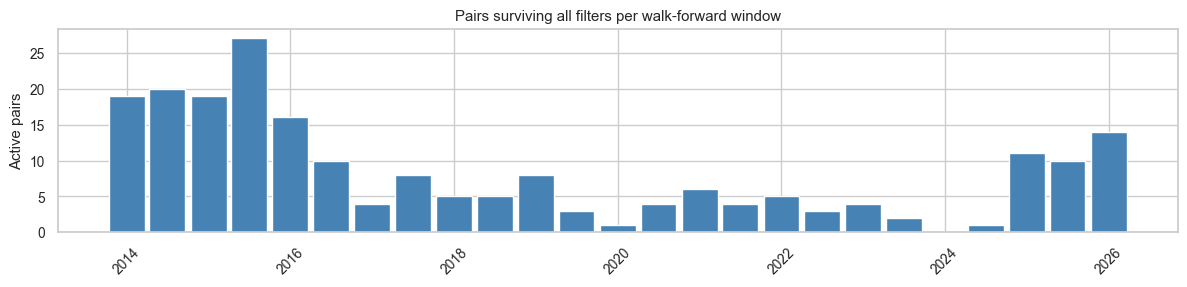

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(
    window_log['trade_start'],
    window_log['n_pairs_filtered'],
    width=160,
    color='steelblue',
    edgecolor='white',
    label='Pairs after filters',
)
ax.set_ylabel('Active pairs')
ax.set_title('Pairs surviving all filters per walk-forward window')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pairs_per_window.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Equity curves

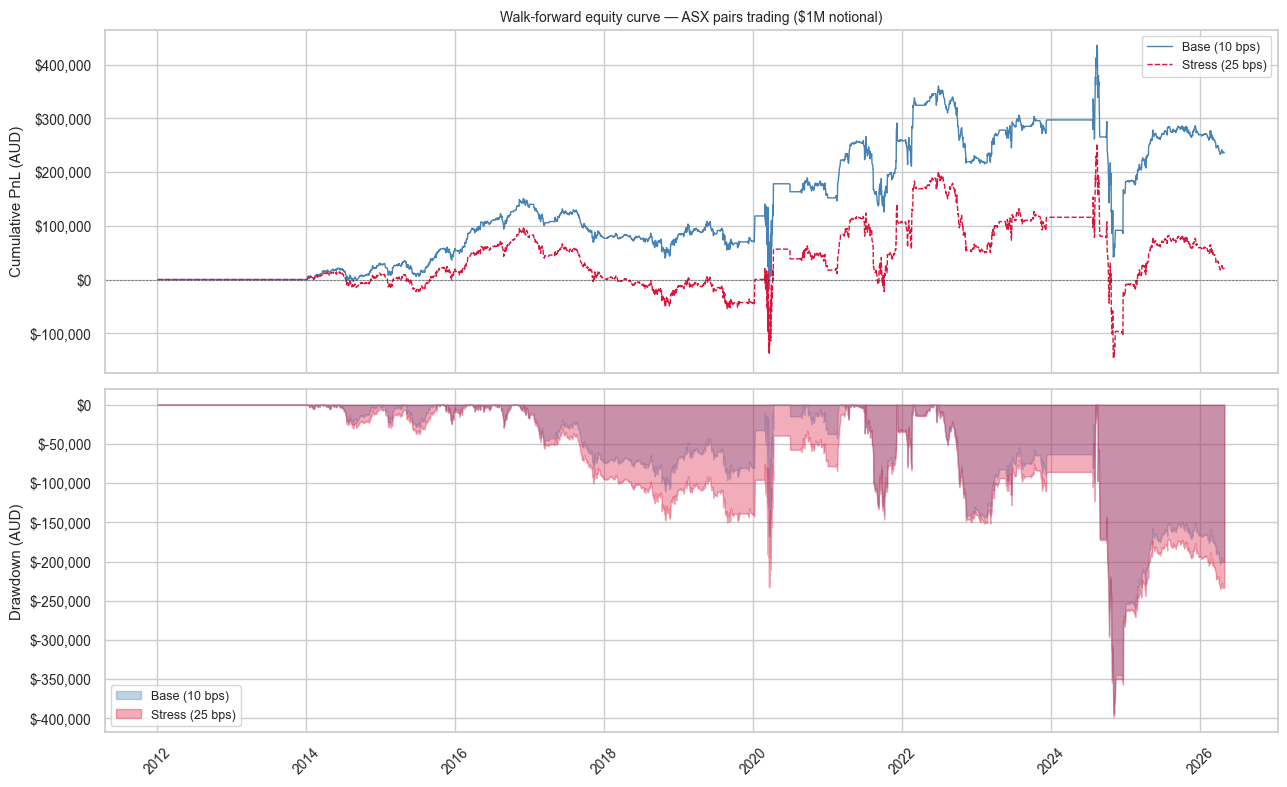

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel 1: Cumulative equity
ax1 = axes[0]
ax1.plot(equity_base.index,   equity_base.values,   linewidth=1.0, color='steelblue', label=f'Base ({BASE_BPS:.0f} bps)')
ax1.plot(equity_stress.index, equity_stress.values, linewidth=1.0, color='crimson',   linestyle='--', label=f'Stress ({STRESS_BPS:.0f} bps)')
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.set_ylabel('Cumulative PnL (AUD)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.set_title(
    f'Walk-forward equity curve — ASX pairs trading (${TOTAL_CAPITAL/1e6:.0f}M notional)',
    fontsize=10,
)

# Panel 2: Drawdown
ax2 = axes[1]
for equity, color, label in [
    (equity_base,   'steelblue', f'Base ({BASE_BPS:.0f} bps)'),
    (equity_stress, 'crimson',   f'Stress ({STRESS_BPS:.0f} bps)'),
]:
    dd = equity - equity.cummax()
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.35, color=color, label=label)

ax2.set_ylabel('Drawdown (AUD)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Overall performance metrics

In [7]:
m_base   = compute_metrics(daily_pnl_base)
m_stress = compute_metrics(daily_pnl_stress)

summary = pd.DataFrame({'Base': m_base, 'Stress': m_stress}).T
fmt = {
    'total_pnl':        '${:,.0f}',
    'ann_return':       '${:,.0f}',
    'ann_vol':          '${:,.0f}',
    'sharpe':           '{:.3f}',
    'sortino':          '{:.3f}',
    'max_drawdown':     '${:,.0f}',
    'max_drawdown_pct': '{:.1%}',
    'avg_daily_pnl':    '${:.0f}',
    'trading_days':     '{:.0f}',
}
for col, f in fmt.items():
    if col in summary.columns:
        summary[col] = summary[col].apply(lambda v: f.format(v) if not (isinstance(v, float) and np.isnan(v)) else 'NaN')

print('Overall performance:')
print(summary.to_string())

Overall performance:
       total_pnl ann_return   ann_vol sharpe sortino max_drawdown max_drawdown_pct avg_daily_pnl trading_days
Base    $236,025    $16,408  $116,765  0.141   0.131    $-394,362           -90.4%           $93         2528
Stress   $19,508     $1,356  $116,648  0.012   0.011    $-398,020          -157.3%            $8         2528


## 5. Per-year breakdown

In [8]:
yearly = pd.DataFrame({
    'pnl_base':   daily_pnl_base.groupby(daily_pnl_base.index.year).sum(),
    'pnl_stress': daily_pnl_stress.groupby(daily_pnl_stress.index.year).sum(),
})

def annual_sharpe(pnl_by_year, full_series):
    """Sharpe per year using that year's actual daily PnL."""
    sharpes = {}
    for year in pnl_by_year.index:
        yr_pnl = full_series[full_series.index.year == year]
        m = compute_metrics(yr_pnl)
        sharpes[year] = m['sharpe']
    return pd.Series(sharpes)

yearly['sharpe_base']   = annual_sharpe(yearly, daily_pnl_base)
yearly['sharpe_stress'] = annual_sharpe(yearly, daily_pnl_stress)

print('Per-year PnL and Sharpe:')
print(yearly.to_string(float_format='{:,.2f}'.format))

Per-year PnL and Sharpe:
        pnl_base  pnl_stress  sharpe_base  sharpe_stress
date                                                    
2012        0.00        0.00          NaN            NaN
2013        0.00        0.00          NaN            NaN
2014   28,575.09    9,071.90         1.14           0.37
2015   25,777.80    6,283.18         0.66           0.16
2016   85,713.46   67,629.93         2.10           1.67
2017  -63,126.44  -82,263.06        -1.54          -2.00
2018    7,501.94  -12,387.20         0.14          -0.24
2019  -13,529.02  -32,558.46        -0.24          -0.58
2020   81,238.46   61,806.87         0.27           0.21
2021  106,308.22   88,140.51         0.81           0.67
2022  -32,585.84  -44,992.95        -0.31          -0.43
2023   71,401.71   55,228.67         0.90           0.70
2024 -114,772.69 -125,177.06        -0.47          -0.52
2025   87,763.86   68,760.43         1.50           1.18
2026  -34,241.64  -40,034.99        -2.50          -2.92


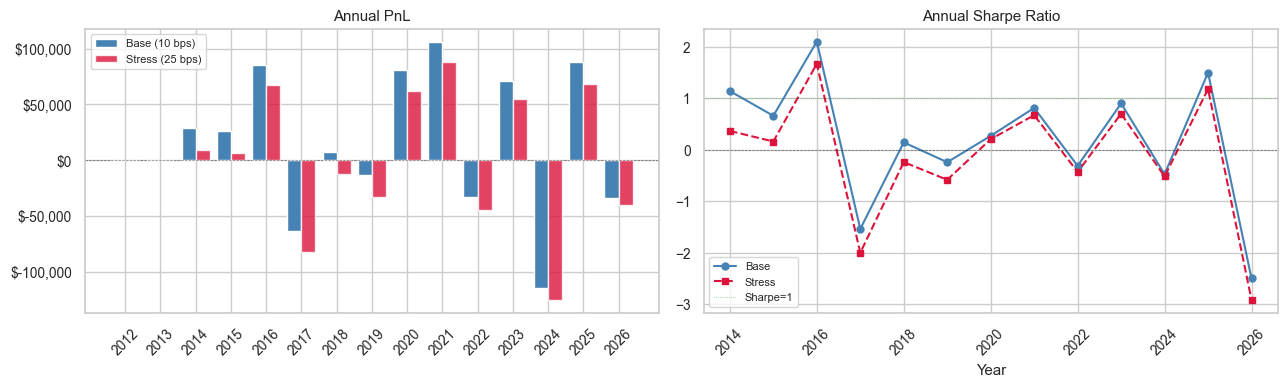

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-year PnL bars
ax = axes[0]
x = np.arange(len(yearly))
w = 0.4
ax.bar(x - w/2, yearly['pnl_base'],   width=w, label=f'Base ({BASE_BPS:.0f} bps)',   color='steelblue')
ax.bar(x + w/2, yearly['pnl_stress'], width=w, label=f'Stress ({STRESS_BPS:.0f} bps)', color='crimson',   alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(yearly.index, rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('Annual PnL')
ax.legend(fontsize=8)

# Per-year Sharpe
ax2 = axes[1]
valid_base   = yearly['sharpe_base'].replace([np.inf, -np.inf], np.nan).dropna()
valid_stress = yearly['sharpe_stress'].replace([np.inf, -np.inf], np.nan).dropna()
ax2.plot(valid_base.index,   valid_base.values,   'o-', color='steelblue', label=f'Base', markersize=5)
ax2.plot(valid_stress.index, valid_stress.values, 's--', color='crimson',   label=f'Stress', markersize=5)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax2.axhline(1, color='green', linewidth=0.5, linestyle=':', alpha=0.6, label='Sharpe=1')
ax2.set_title('Annual Sharpe Ratio')
ax2.set_xlabel('Year')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'annual_pnl_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trade statistics

In [10]:
if len(trade_log) > 0:
    print(f'Total trades:             {len(trade_log)}')
    print(f'Unique pairs traded:      {trade_log["pair_id"].nunique()}')
    print(f'Average holding (bars):   {trade_log["holding_bars"].mean():.1f} trading days')
    print()
    print('Exit reason breakdown:')
    print(trade_log['exit_reason'].value_counts().to_string())
    print()
    print('Top 10 most-traded pairs:')
    print(trade_log['pair_id'].value_counts().head(10).to_string())
else:
    print('No completed trades.')

Total trades:             447
Unique pairs traded:      74
Average holding (bars):   16.4 trading days

Exit reason breakdown:
exit_reason
mean_revert    245
time_stop      138
hard_stop       15

Top 10 most-traded pairs:
pair_id
VCX.AX/CHC.AX    22
DXS.AX/CHC.AX    17
SGP.AX/CHC.AX    15
SCG.AX/VCX.AX    13
CSL.AX/FPH.AX    13
SGP.AX/MGR.AX    12
IAG.AX/SUN.AX    12
WOW.AX/TWE.AX    11
WDS.AX/YAL.AX    11
MGR.AX/CHC.AX    10


## 7. Assessment

In [11]:
m_base   = compute_metrics(daily_pnl_base)
m_stress = compute_metrics(daily_pnl_stress)

sharpe_b = m_base['sharpe']
sharpe_s = m_stress['sharpe']
cost_drag = m_base['total_pnl'] - m_stress['total_pnl']

print('=' * 60)
print('BACKTEST ASSESSMENT')
print('=' * 60)
print()
print(f'Base Sharpe:    {sharpe_b:.3f}')
print(f'Stress Sharpe:  {sharpe_s:.3f}')
print(f'Cost drag:      ${cost_drag:,.0f} ({cost_drag/TOTAL_CAPITAL:.1%} of capital)')
print()

# Alpha decay: is Sharpe declining over time?
years = sorted(yearly.index)
if len(years) >= 4:
    recent_sharpe = yearly.loc[years[-3:], 'sharpe_base'].mean()
    early_sharpe  = yearly.loc[years[:3],  'sharpe_base'].mean()
    print(f'Early-period avg Sharpe (first 3 years):  {early_sharpe:.3f}')
    print(f'Recent-period avg Sharpe (last 3 years):  {recent_sharpe:.3f}')
    if recent_sharpe < early_sharpe - 0.3:
        print('NOTE: Sharpe has declined meaningfully — consistent with alpha decay.')
        print('      Phase 5 should include a formal Sharpe-vs-year regression.')
    elif recent_sharpe < 0 and early_sharpe > 0:
        print('NOTE: Strategy turned negative in recent years — significant regime change.')
    else:
        print('NOTE: Sharpe is relatively stable across the sample.')
    print()

# Time-stop rate as a regime indicator
if len(trade_log) > 0:
    ts_rate = (trade_log['exit_reason'] == 'time_stop').mean()
    print(f'Time-stop rate: {ts_rate:.1%}')
    if ts_rate > 0.5:
        print('  High time-stop rate — most positions did not revert within 2×HL.')
        print('  This could indicate: half-life mis-estimation, spread mean-shift, or')
        print('  regime-specific behaviour. Phase 5 should decompose by period.')
    else:
        print('  Time-stop rate within normal range.')
    print()

# Honest summary
print('Limitations to document in Phase 5 writeup:')
print('  - Survivorship bias: only currently-listed tickers are included.')
print('  - Price data: yfinance adj_close; not point-in-time; no corporate action audit.')
print('  - Cost model: flat bps, no market impact, no borrow cost for short legs.')
print('  - Capacity: position sizes vs ADV not checked; results may not be scalable.')
print('  - Multiple testing: ~94-pair search space; BH corrects within-sector only.')

BACKTEST ASSESSMENT

Base Sharpe:    0.141
Stress Sharpe:  0.012
Cost drag:      $216,517 (21.7% of capital)

Early-period avg Sharpe (first 3 years):  1.141
Recent-period avg Sharpe (last 3 years):  -0.493
NOTE: Sharpe has declined meaningfully — consistent with alpha decay.
      Phase 5 should include a formal Sharpe-vs-year regression.

Time-stop rate: 30.9%
  Time-stop rate within normal range.

Limitations to document in Phase 5 writeup:
  - Survivorship bias: only currently-listed tickers are included.
  - Price data: yfinance adj_close; not point-in-time; no corporate action audit.
  - Cost model: flat bps, no market impact, no borrow cost for short legs.
  - Capacity: position sizes vs ADV not checked; results may not be scalable.
  - Multiple testing: ~94-pair search space; BH corrects within-sector only.
